# Native VTK pieces and legacy structured grids

Serial VTP/VTS/VTR/VTI pieces concatenate in file order without welding boundaries or removing ghost cells. This example reads two touching ImageData pieces, preserving each cell's material id, and a big-endian legacy rectilinear grid produced by VTK. Both use the native core; writers remain unchanged. Rendering uses off-screen PyVista embedded in matplotlib, with a matplotlib fallback if GL is unavailable.

In [1]:
import tempfile
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import vtk
import meshioplusplus as mio
from meshioplusplus import _core

pv.OFF_SCREEN = True
tmp = tempfile.TemporaryDirectory()
directory = Path(tmp.name)
pieces = []
for part in range(2):
    values = ' '.join([str(part + 1)] * 24)
    pieces.append(f'''<Piece Extent='{part*4} {(part+1)*4} 0 3 0 2'><CellData>
      <DataArray type='Int32' Name='material' format='ascii'>{values}</DataArray>
      </CellData></Piece>''')
xml = "<VTKFile type='ImageData'><ImageData WholeExtent='0 8 0 3 0 2' Spacing='0.25 0.3 0.4'>" + ''.join(pieces) + '</ImageData></VTKFile>'
path = directory / 'pieces.vti'
path.write_text(xml)
assembled = _core.vti_read(str(path))
summary = mio.read_metadata(path)
print(f'XML pieces: {summary["num_points"]} points, {summary["num_cells"]} cells; shared boundary points intentionally remain duplicated.')
np.testing.assert_array_equal(assembled.cell_data['material'][0], [1]*24 + [2]*24)

source = pv.RectilinearGrid(np.array([0., 0.1, 0.4, 0.9, 1.5, 2.]), np.linspace(0, 0.9, 4), np.linspace(0, 0.8, 3))
source.cell_data['material'] = np.arange(source.n_cells) % 2 + 1
legacy_path = directory / 'graded.vtk'
writer = vtk.vtkRectilinearGridWriter()
writer.SetInputData(source)
writer.SetFileName(str(legacy_path))
writer.SetFileTypeToBinary()
assert writer.Write() == 1
legacy = _core.vtk_read(str(legacy_path))
np.testing.assert_array_equal(legacy.points, source.points)
print(f'Legacy rectilinear grid: {len(legacy.points)} points, {sum(len(cb.data) for cb in legacy.cells)} cells; big-endian binary, native read.')


XML pieces: 120 points, 48 cells; shared boundary points intentionally remain duplicated.
Legacy rectilinear grid: 72 points, 30 cells; big-endian binary, native read.


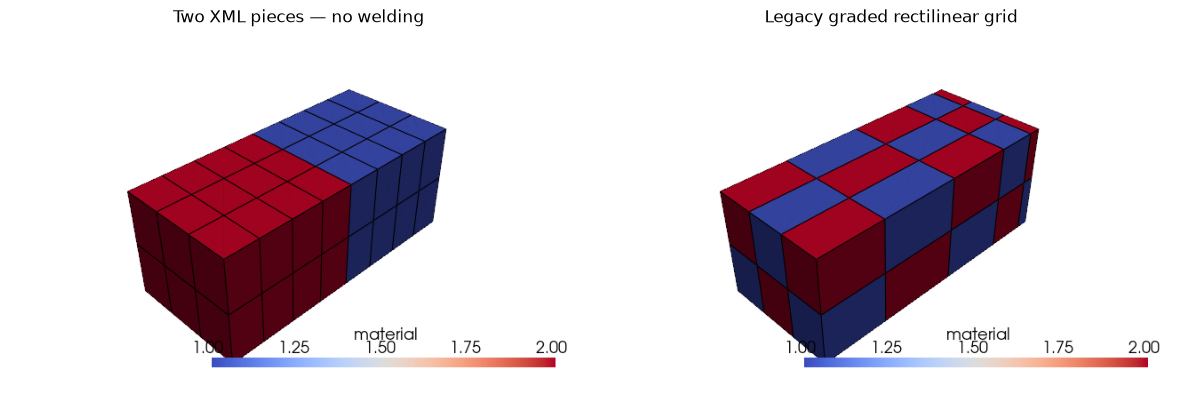

In [2]:
fig = plt.figure(figsize=(12, 4))
for index, (title, mesh) in enumerate([('Two XML pieces — no welding', assembled), ('Legacy graded rectilinear grid', legacy)], 1):
    plotter = None
    try:
        plotter = pv.Plotter(off_screen=True, window_size=(650, 400))
        plotter.add_mesh(mio.to_pyvista(mesh), scalars='material', show_edges=True, cmap='coolwarm', clim=(1, 2))
        plotter.camera_position = 'iso'
        image = plotter.screenshot(return_img=True)
        ax = fig.add_subplot(1, 2, index)
        ax.imshow(image)
        ax.axis('off')
    except Exception as exc:
        print(f'Matplotlib fallback: {type(exc).__name__}')
        ax = fig.add_subplot(1, 2, index, projection='3d')
        ax.scatter(*mesh.points.T, c=mesh.points[:, 0], cmap='coolwarm', s=15)
    finally:
        if plotter is not None:
            plotter.close()
    ax.set_title(title)
fig.tight_layout()
plt.show()
tmp.cleanup()
